# 2. Check the mosaic, before and after the hollow correction

Run this after step 4 of [docs/REPRODUCTION.md](../docs/REPRODUCTION.md), on the
mosaic you produced. It answers, in order:

1. **is the file to specification?** grid, CRS, 231 bands, wavelength labels, compression;
2. **is it really this checkpoint's output?** the mosaic is re-predicted from the MDIS
   input on a window and compared pixel by pixel;
3. **does it look like Mercury?** band statistics against the reference run;
4. **what does the optional hollow correction change?** the layer is opened, the two
   rasters are differenced, and the difference is verified to be exactly the fixed
   residual, on the selection pixels and nowhere else.

Everything reads small windows: a full-extent read of a 158 GB DEFLATE file with no
overviews would decompress every tile. Total runtime is a couple of minutes.

In [21]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import torch
from rasterio.windows import from_bounds

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO / "src"))

from mdis2vihi.lit.spectral_module import SpectralLitModule  # noqa: E402
from mdis2vihi.models.mlp import SpectralMLP  # noqa: E402

MOSAIC = REPO / "runs/final/mdis2vihi_global_final_deflate.tif"
CORRECTED = REPO / "runs/final/mdis2vihi_global_final_postcorr_unionbb0.8_deflate.tif"
MDIS = REPO / ("data/raw/mdis_mosaic/MDIS_MDR_20170512_PDS16_64ppd_"
               "equirectangular_withbackplanes.tif")
CKPTS = sorted((REPO / "runs/final/lightning_logs/version_0/checkpoints").glob("epoch=*.ckpt"))
STATS = json.loads((REPO / "runs/final/emission_stats.json").read_text(encoding="utf-8"))
LAYER_DIR = REPO / "runs/final/correction"
BANDSTATS = REPO / "runs/final/eval/mosaic_band_stats_final.csv"

GRID_NM = np.arange(300.0, 1450.0 + 5.0, 5.0)
NODATA = -1e30
R_MERC = 2_439_400.0
IDX = {435: 27, 560: 52, 750: 90, 995: 139, 1450: 230}      # index on the 5 nm grid

HAVE_MOSAIC, HAVE_CORRECTED, HAVE_MDIS = MOSAIC.exists(), CORRECTED.exists(), MDIS.exists()
CHECKS = []


def check(name, ok, detail=""):
    CHECKS.append({"check": name, "result": "PASS" if ok else "FAIL", "detail": detail})
    print(f"[{'PASS' if ok else 'FAIL'}]  {name}" + (f"    {detail}" if detail else ""))
    return bool(ok)


def window_at(ds, lon, lat, half_deg):
    # Square window centred on a lon/lat, in the mosaic's projected CRS.
    lon = lon - 360 if lon > 180 else lon
    return from_bounds(np.radians(lon - half_deg) * R_MERC, np.radians(lat - half_deg) * R_MERC,
                       np.radians(lon + half_deg) * R_MERC, np.radians(lat + half_deg) * R_MERC,
                       ds.transform).round_offsets().round_lengths()


# Some IDEs inject their own (often dark) matplotlib theme into the kernel, which
# would render this notebook's figures with white text on a white background.
# Reset to the matplotlib defaults so the figures look the same for everyone.
plt.style.use("default")
plt.rcParams.update({"figure.dpi": 110, "figure.facecolor": "white",
                     "savefig.facecolor": "white", "axes.facecolor": "white",
                     "axes.grid": True, "grid.alpha": 0.3})
print(f"mosaic on disk: {HAVE_MOSAIC} | corrected variant: {HAVE_CORRECTED} | "
      f"MDIS input: {HAVE_MDIS}")
print(f"checkpoint: {CKPTS[0].name if CKPTS else 'MISSING'}")

mosaic on disk: True | corrected variant: True | MDIS input: True
checkpoint: epoch=93-step=10340.ckpt


## 1. Is the file to specification?

The specification is in [docs/DELIVERABLE.md](../docs/DELIVERABLE.md): Float32, 231 bands on
5 nm x [300, 1450] nm, the MDIS grid and CRS unchanged, DEFLATE with **PREDICTOR=2**,
and one `'lambda nm'` description per band.

In [22]:
if not HAVE_MOSAIC:
    print("skipped: no mosaic on disk. Produce it with step 4 of docs/REPRODUCTION.md")
else:
    with rasterio.open(MOSAIC) as ds:
        prof = ds.profile
        struct = ds.tags(ns="IMAGE_STRUCTURE")
        desc = list(ds.descriptions)
        size_gb = MOSAIC.stat().st_size / 2 ** 30
        summary = {"width": ds.width, "height": ds.height, "count": ds.count,
                   "dtype": ds.dtypes[0], "nodata": ds.nodata,
                   "res_m": ds.transform.a, "block_shape": ds.block_shapes[0],
                   "compression": struct.get("COMPRESSION"),
                   "predictor": struct.get("PREDICTOR"),
                   "interleave": struct.get("INTERLEAVE"),
                   "size_GB": round(size_gb, 2)}

    wl = np.array([float(d.split()[0]) for d in desc if d])
    check("231 bands", summary["count"] == 231, f"{summary['count']} bands")
    check("Float32, no quantisation", summary["dtype"] == "float32", summary["dtype"])
    check("the MDIS grid is preserved (23040 x 11521 at 665.243 m)",
          summary["width"] == 23040 and summary["height"] == 11521
          and abs(summary["res_m"] - 665.24315270546) < 1e-6,
          f"{summary['width']} x {summary['height']} at {summary['res_m']:.6f} m")
    check("every band is labelled with its wavelength",
          len(wl) == 231 and np.allclose(wl, GRID_NM),
          f"{desc[0]} ... {desc[-1]}")
    check("lossless DEFLATE with PREDICTOR=2",
          struct.get("COMPRESSION") == "DEFLATE" and struct.get("PREDICTOR") == "2",
          f"{struct.get('COMPRESSION')}, predictor {struct.get('PREDICTOR')}")
    check("nodata is the MDIS nodata value", summary["nodata"] < NODATA, f"{summary['nodata']:.6e}")
    display(pd.Series(summary).to_frame("value"))

[PASS]  231 bands    231 bands
[PASS]  Float32, no quantisation    float32
[PASS]  the MDIS grid is preserved (23040 x 11521 at 665.243 m)    23040 x 11521 at 665.243153 m
[PASS]  every band is labelled with its wavelength    300 nm ... 1450 nm
[PASS]  lossless DEFLATE with PREDICTOR=2    DEFLATE, predictor 2
[PASS]  nodata is the MDIS nodata value    -3.402823e+38


,value
width,23040
height,11521
count,231
dtype,float32
nodata,-340282265508890445205022487695511781376.0
res_m,665.243153
block_shape,"(256, 512)"
compression,DEFLATE
predictor,2
interleave,PIXEL


## 2. Is it really this checkpoint's output?

This checkup catches a mosaic written with the wrong
checkpoint, without the emission input, or with mismatched standardisation statistics.
A window of the MDIS mosaic is read, pushed through the committed checkpoint, and
compared with the same window of the produced mosaic.

The model takes **nine** inputs: the 8 MDIS I/F bands plus band 9, the emission angle,
z-standardised with the training statistics in `runs/final/emission_stats.json`. Feed
it eight and it will not load; feed it a different standardisation and it will produce
plausible nonsense, which is why this check compares the numbers.

[PASS]  the mosaic reproduces the checkpoint pixel by pixel    max |difference| = 1.12e-07 I/F over 1,024 pixels x 231 bands, max spectral angle 3.96e-02 deg
[PASS]  nodata is propagated as a whole spectrum, never band by band    0 invalid pixels in this window


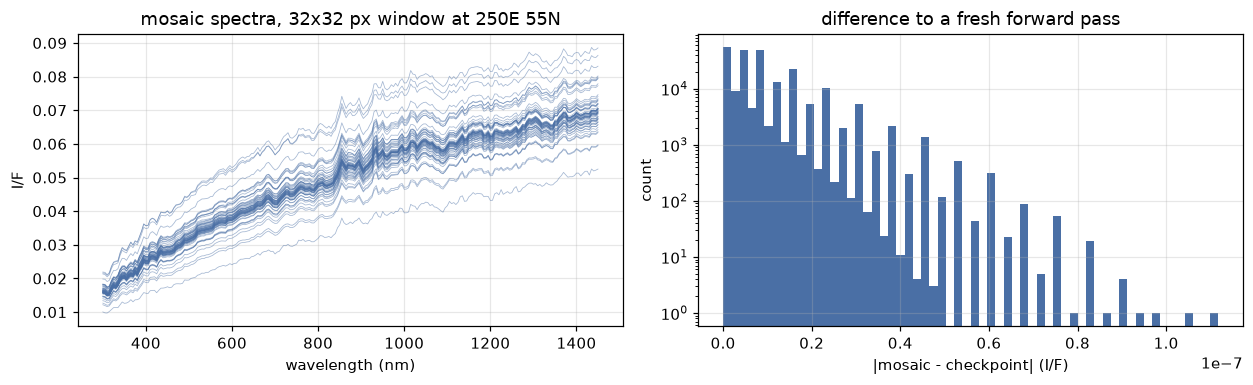

In [23]:
if not (HAVE_MOSAIC and HAVE_MDIS and CKPTS):
    print("skipped: needs the mosaic, the MDIS input and the checkpoint")
else:
    model = SpectralLitModule.load_from_checkpoint(
        str(CKPTS[0]),
        model=SpectralMLP(in_features=STATS["in_features"], out_features=231,
                          hidden=tuple(STATS["hidden"])),
        map_location="cpu").eval().model

    with rasterio.open(MOSAIC) as dd, rasterio.open(MDIS) as dm:
        win = window_at(dd, 250.0, 55.0, 0.25)          # northern smooth plains
        x9 = dm.read(list(range(1, 10)), window=win).astype(np.float32)
        got = dd.read(window=win).astype(np.float32)

    valid = np.all(np.isfinite(x9) & (x9 > NODATA), axis=0)
    xs = x9[:, valid].T.copy()
    xs[:, 8] = (xs[:, 8] - STATS["emission_mean"]) / STATS["emission_std"]
    with torch.no_grad():
        pred = model(torch.from_numpy(xs)).numpy()
    obs = got[:, valid].T

    dmax = float(np.abs(pred - obs).max())
    cos = ((pred * obs).sum(1)
           / (np.linalg.norm(pred, axis=1) * np.linalg.norm(obs, axis=1) + 1e-12))
    sam = float(np.degrees(np.arccos(np.clip(cos, -1, 1))).max())

    check("the mosaic reproduces the checkpoint pixel by pixel", dmax < 1e-5,
          f"max |difference| = {dmax:.2e} I/F over {int(valid.sum()):,} pixels "
          f"x 231 bands, max spectral angle {sam:.2e} deg")
    check("nodata is propagated as a whole spectrum, never band by band",
          bool(np.all((got <= NODATA).sum(axis=0)[~valid] == 231)) if (~valid).any() else True,
          f"{int((~valid).sum()):,} invalid pixels in this window")

    fig, ax = plt.subplots(1, 2, figsize=(11.5, 3.6))
    for k in range(0, obs.shape[0], max(1, obs.shape[0] // 60)):
        ax[0].plot(GRID_NM, obs[k], lw=0.5, alpha=0.5, color="#4a6fa5")
    ax[0].set(xlabel="wavelength (nm)", ylabel="I/F",
              title=f"mosaic spectra, {win.width}x{win.height} px window at 250E 55N")
    ax[1].hist(np.abs(pred - obs).ravel(), bins=60, color="#4a6fa5")
    ax[1].set(xlabel="|mosaic - checkpoint| (I/F)", ylabel="count", yscale="log",
              title="difference to a fresh forward pass")
    fig.tight_layout()

## 3. Does it look like Mercury?

Windows are sampled across the globe and compared with the reference run
(`runs/final/eval/mosaic_consistency_final.json`, 352 windows, 41 M valid pixels).
The signature to recover is Mercury's dark, red surface: I/F around 0.047 overall and
a 750/435 nm slope near +64 %.

These are order-of-magnitude checks on a small sample; the reference numbers come from
a much larger pass, so a few percent of difference is expected.

14 windows of 128 x 128 px sampled
  R435   0.0236   reference 0.0248
  R750   0.0391   reference 0.0407
  R1450  0.0614   reference 0.0628
[PASS]  reflectance level matches the reference run    R435 0.0236, R750 0.0391, R1450 0.0614
[PASS]  the surface is red: 750/435 nm slope near +64 %    +65.5 %


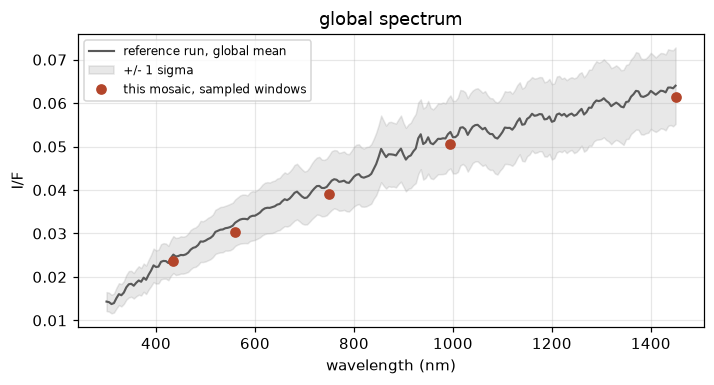

In [24]:
REF = {"R435": 0.0248, "R750": 0.0407, "R1450": 0.0628, "red_slope_pct": 64.1,
       "median_iof": 0.0471}

if not HAVE_MOSAIC:
    print("skipped: no mosaic on disk")
else:
    rng = np.random.default_rng(42)
    bands = [IDX[435], IDX[560], IDX[750], IDX[995], IDX[1450]]
    got, tried = [], 0
    with rasterio.open(MOSAIC) as ds:
        while len(got) < 14 and tried < 40:
            tried += 1
            r = int(rng.integers(300, ds.height - 428))
            c = int(rng.integers(0, ds.width - 128))
            a = ds.read([b + 1 for b in bands], window=rasterio.windows.Window(c, r, 128, 128))
            a = np.where(a <= NODATA, np.nan, a)
            if np.isfinite(a[0]).mean() > 0.9:
                got.append(np.nanmedian(a.reshape(len(bands), -1), axis=1))
    S = np.array(got)
    med = np.nanmedian(S, axis=0)
    slope = 100.0 * (med[2] / med[0] - 1.0)

    print(f"{len(S)} windows of 128 x 128 px sampled")
    for name, k, ref in [("R435", 0, REF["R435"]), ("R750", 2, REF["R750"]),
                         ("R1450", 4, REF["R1450"])]:
        print(f"  {name:6s} {med[k]:.4f}   reference {ref:.4f}")
    check("reflectance level matches the reference run",
          all(abs(med[k] - r) / r < 0.25 for k, r in [(0, REF["R435"]), (2, REF["R750"]),
                                                      (4, REF["R1450"])]),
          f"R435 {med[0]:.4f}, R750 {med[2]:.4f}, R1450 {med[4]:.4f}")
    check("the surface is red: 750/435 nm slope near +64 %",
          abs(slope - REF["red_slope_pct"]) < 15.0, f"{slope:+.1f} %")

    ms = pd.read_csv(BANDSTATS)
    fig, ax = plt.subplots(figsize=(6.6, 3.6))
    ax.plot(ms.wavelength_nm, ms["mean"], color="0.35", lw=1.4,
            label="reference run, global mean")
    ax.fill_between(ms.wavelength_nm, ms["mean"] - ms["std"], ms["mean"] + ms["std"],
                    color="0.5", alpha=0.18, label="+/- 1 sigma")
    ax.plot([435, 560, 750, 995, 1450], med, "o", color="#b3452a",
            label="this mosaic, sampled windows")
    ax.set(xlabel="wavelength (nm)", ylabel="I/F", title="global spectrum")
    ax.legend(fontsize=8)
    fig.tight_layout()

## 4. What the mosaic looks like on three known sites

Predicted spectra, median over a small window, on three units with distinct spectral
behaviour. This is an eyeball check, not a validation.

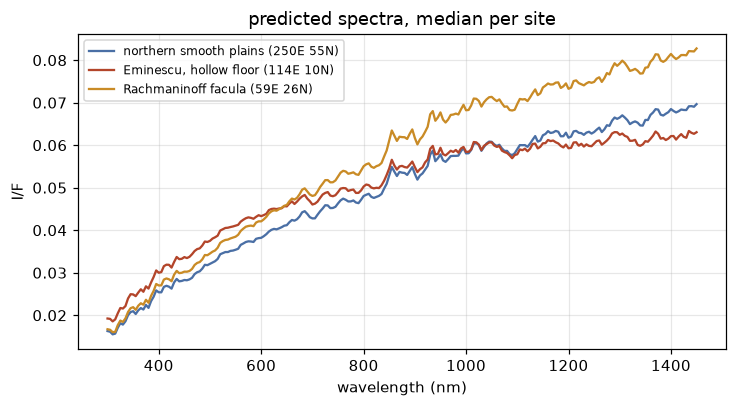

In [25]:
SITES = [("northern smooth plains", 250.00, 55.00, "#4a6fa5"),
         ("Eminescu, hollow floor", 114.14, 10.31, "#b3452a"),
         ("Rachmaninoff facula", 59.48, 26.20, "#c98b26")]

if not HAVE_MOSAIC:
    print("skipped: no mosaic on disk")
else:
    fig, ax = plt.subplots(figsize=(6.8, 3.8))
    with rasterio.open(MOSAIC) as ds:
        for name, lon, lat, colour in SITES:
            a = ds.read(window=window_at(ds, lon, lat, 0.10)).astype(np.float32)
            a = np.where(a <= NODATA, np.nan, a)
            spec = np.nanmedian(a.reshape(231, -1), axis=1)
            ax.plot(GRID_NM, spec, color=colour, label=f"{name} ({lon:.0f}E {lat:.0f}N)")
    ax.set(xlabel="wavelength (nm)", ylabel="I/F", title="predicted spectra, median per site")
    ax.legend(fontsize=8)
    fig.tight_layout()

## 5. The optional hollow-correction layer

Hollows are the model's known weak point: the `q1` quality filter excludes
hollow-floor footprints from training, so the mosaic **extrapolates** there and
under-predicts their contrast. The optional correction adds a rank-2 residual on
the pixels where a hollow catalogue and a bright-and-blue spectral test agree.

The whole layer is five numbers per corrected pixel, `row, col, g, c0, c1`, plus a
fixed 231 x 2 basis `B`:

$$\mathrm{corrected} = \mathrm{deliverable} + g \cdot (c \; B^\top)$$

Outside those pixels the correction is exactly zero, which is why the model output mosaic
stays the reference product and the corrected one is a separate file.

In [26]:
cfg = json.loads((LAYER_DIR / "correction_config.json").read_text(encoding="utf-8"))
layer = pd.read_parquet(LAYER_DIR / cfg["files"]["layer"])
B = np.load(LAYER_DIR / "residual_basis_rank2.npz")["B"]

selection, built = cfg["selection"], cfg["layer"]
print(f"catalogues: {selection['n_thomas']} Thomas disks, {selection['hornet']['n_kept']} HORNET "
      f"polygons (variant {selection['hornet_variant']})")
print(f"spatial stage: {built['n_pixels_spatial']:,} px -> bright+blue stage rejects "
      f"{built['n_pixels_rejected_bright_blue']:,} -> {built['n_pixels_corrected']:,} corrected")

check("the layer holds 115 112 pixels", len(layer) == 115_112, f"{len(layer):,}")
check("that is 0.043 % of the mosaic", abs(built["fraction_mosaic_pct"] - 0.043) < 0.002,
      f"{built['fraction_mosaic_pct']:.5f} %")
check("the residual basis is rank 2 over 231 bands", B.shape == (231, 2), str(B.shape))
check("the selection amplitude g is the fixed 0.5", float(layer.g.min()) == float(layer.g.max()) == 0.5,
      f"g = {layer.g.iloc[0]}")
layer.head()

catalogues: 608 Thomas disks, 3205 HORNET polygons (variant 0.8)
spatial stage: 432,295 px -> bright+blue stage rejects 317,135 -> 115,112 corrected
[PASS]  the layer holds 115 112 pixels    115,112
[PASS]  that is 0.043 % of the mosaic    0.04337 %
[PASS]  the residual basis is rank 2 over 231 bands    (231, 2)
[PASS]  the selection amplitude g is the fixed 0.5    g = 0.5


,row,col,g,c0,c1
0,682,1832,0.5,-1.904020,-0.158227
1,682,1833,0.5,-1.887390,-0.155304
2,682,1834,0.5,-1.833646,-0.148436
3,682,1835,0.5,-1.777996,-0.141631
4,682,1836,0.5,-1.731532,-0.136019


Where those pixels are, and what the correction does spectrally.

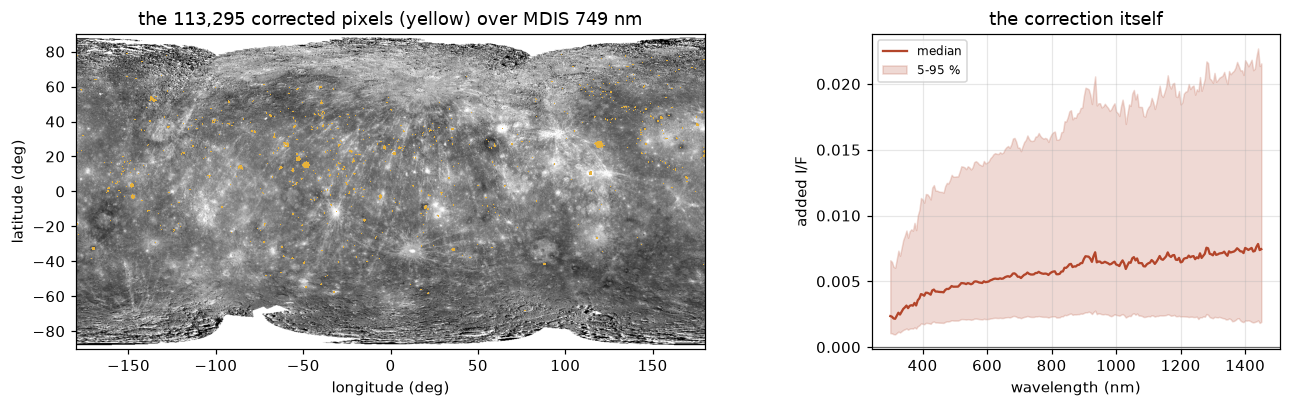

In [27]:
with rasterio.open(MOSAIC if HAVE_MOSAIC else MDIS) as ds:
    T = ds.transform
xs, ys = T * (layer.col.to_numpy() + 0.5, layer.row.to_numpy() + 0.5)
lons, lats = np.degrees(xs / R_MERC), np.degrees(ys / R_MERC)

fig, ax = plt.subplots(1, 2, figsize=(12.5, 3.8),
                       gridspec_kw={"width_ratios": [1.9, 1]})
if HAVE_MDIS:
    with rasterio.open(MDIS) as dm:
        back = dm.read([5], out_shape=(1, dm.height // 16, dm.width // 16))[0].astype(np.float32)
    back[back <= NODATA] = np.nan
    ax[0].imshow(back, extent=[-180, 180, -90, 90], cmap="gray",
                 vmin=np.nanpercentile(back, 2), vmax=np.nanpercentile(back, 98))
ax[0].scatter(lons, lats, s=0.4, color="#e8b23a", linewidths=0)
ax[0].set(xlim=(-180, 180), ylim=(-90, 90), xlabel="longitude (deg)",
          ylabel="latitude (deg)", aspect="equal",
          title=f"the {len(layer):,} corrected pixels (yellow) over MDIS 749 nm")
ax[0].grid(False)

delta = layer.g.to_numpy(np.float32)[:, None] * (layer[["c0", "c1"]].to_numpy(np.float32) @ B.T)
ax[1].plot(GRID_NM, np.median(delta, axis=0), color="#b3452a", label="median")
ax[1].fill_between(GRID_NM, np.percentile(delta, 5, axis=0),
                   np.percentile(delta, 95, axis=0), color="#b3452a", alpha=0.2,
                   label="5-95 %")
ax[1].axhline(0, color="0.4", lw=0.8)
ax[1].set(xlabel="wavelength (nm)", ylabel="added I/F", title="the correction itself")
ax[1].legend(fontsize=8)
fig.tight_layout()

## 6. Before and after, on the actual rasters

Two windows: a catalogued hollow, where the selection must fire, and a patch of northern
plains, where it must not. Two properties are verified on the real files rather than
asserted:

* **outside the selection the two mosaics are identical**, bit for bit;
* **inside the selection the difference is exactly** $g \cdot (c\,B^\top)$, recomputed here
  from the layer and the basis.

[PASS]  outside the selection the two mosaics are bit-identical    max |difference| = 0.0e+00
[PASS]  inside the selection the difference is exactly the fixed correction network    max deviation = 3.7e-09
[PASS]  the selection fires on the hollow window and not on the control    56.8 % vs 0.0 %


,window,valid px,selection on (%),max diff outside selection,max diff to correction inside selection,median dR995 inside selection
0,Eminescu (hollows),1444,56.79,0.0,3.725290e-09,0.01701
1,northern plains (control),1444,0.00,0.0,0.000000e+00,0.00000


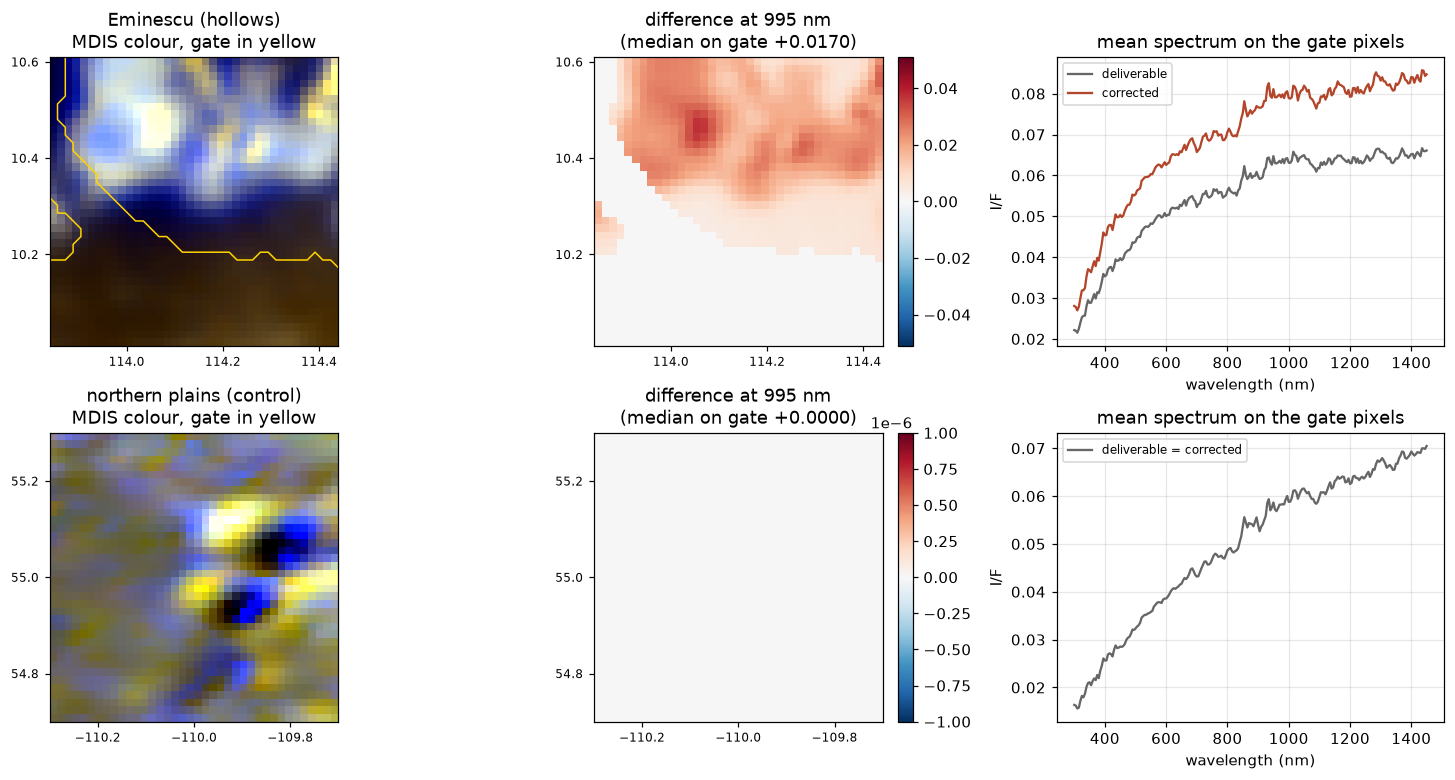

In [28]:
ROIS = [("Eminescu (hollows)", 114.14, 10.31), ("northern plains (control)", 250.00, 55.00)]

if not (HAVE_MOSAIC and HAVE_CORRECTED):
    print("skipped: needs both the mosaic and its corrected variant "
          "(scripts/tools/apply_hollow_correction.py)")
else:
    with rasterio.open(MOSAIC) as d0:
        W = d0.width
    key = layer.row.to_numpy(np.int64) * W + layer.col.to_numpy(np.int64)
    order = np.argsort(key)
    key = key[order]
    gsort = layer.g.to_numpy(np.float32)[order]
    csort = layer[["c0", "c1"]].to_numpy(np.float32)[order]

    def layer_at(rows, cols):
        # (row, col) -> (g, coefficients), zero where the pixel is not in the layer
        k = np.asarray(rows, np.int64) * W + np.asarray(cols, np.int64)
        i = np.clip(np.searchsorted(key, k), 0, len(key) - 1)
        hit = key[i] == k
        return np.where(hit, gsort[i], 0.0), np.where(hit[:, None], csort[i], 0.0)

    fig, axes = plt.subplots(len(ROIS), 3, figsize=(13.5, 3.6 * len(ROIS)))
    rows_out = []
    with rasterio.open(MOSAIC) as d0, rasterio.open(CORRECTED) as d1, rasterio.open(MDIS) as dm:
        for i, (name, lon, lat) in enumerate(ROIS):
            win = window_at(d0, lon, lat, 0.30)
            before = d0.read(window=win).astype(np.float32)
            after = d1.read(window=win).astype(np.float32)
            mdis = dm.read([1, 3, 5], window=win).astype(np.float32)
            h, w = before.shape[1], before.shape[2]
            rr, cc = np.meshgrid(np.arange(h), np.arange(w), indexing="ij")
            g, coef = layer_at((rr + int(win.row_off)).ravel(), (cc + int(win.col_off)).ravel())
            expected = (g[:, None] * (coef @ B.T)).T.reshape(231, h, w)
            gmap = g.reshape(h, w)

            valid = np.all(np.isfinite(before) & (before > NODATA), axis=0)
            on, off = (gmap > 0) & valid, (gmap == 0) & valid
            diff = after - before
            off_max = float(np.abs(diff[:, off]).max()) if off.any() else 0.0
            res_max = float(np.abs(diff[:, on] - expected[:, on]).max()) if on.any() else 0.0
            d995 = float(np.median(diff[IDX[995]][on])) if on.any() else 0.0

            rows_out.append({"window": name, "valid px": int(valid.sum()),
                             "selection on (%)": round(100 * on.sum() / max(valid.sum(), 1), 2),
                             "max diff outside selection": off_max,
                             "max diff to correction inside selection": res_max,
                             "median dR995 inside selection": round(d995, 5)})

            lo = lon - 360 if lon > 180 else lon
            ext = [lo - 0.30, lo + 0.30, lat - 0.30, lat + 0.30]

            def stretch(a):
                p0, p1 = np.nanpercentile(a, 2), np.nanpercentile(a, 98)
                return np.clip((a - p0) / (p1 - p0 + 1e-9), 0, 1)

            blue = np.divide(mdis[0], mdis[2], out=np.full_like(mdis[0], np.nan),
                             where=mdis[2] > 0)
            axes[i, 0].imshow(np.dstack([stretch(mdis[2]), stretch(mdis[1]), stretch(blue)]),
                              extent=ext, origin="upper", aspect="equal")
            if on.any():
                axes[i, 0].contour(np.linspace(ext[0], ext[1], w),
                                   np.linspace(ext[3], ext[2], h), gmap,
                                   levels=[1e-6], colors="#ffd400", linewidths=1.0)
            axes[i, 0].set(title=f"{name}\nMDIS colour, selection in yellow")
            im = axes[i, 1].imshow(np.where(valid, diff[IDX[995]], np.nan), extent=ext,
                                   origin="upper", aspect="equal", cmap="RdBu_r",
                                   vmin=-max(abs(d995) * 3, 1e-6),
                                   vmax=max(abs(d995) * 3, 1e-6))
            axes[i, 1].set(title=f"difference at 995 nm\n(median on selection {d995:+.4f})")
            fig.colorbar(im, ax=axes[i, 1], fraction=0.046, pad=0.04)
            if on.any():
                axes[i, 2].plot(GRID_NM, np.nanmean(before[:, on], axis=1), color="0.4",
                                label="deliverable")
                axes[i, 2].plot(GRID_NM, np.nanmean(after[:, on], axis=1), color="#b3452a",
                                label="corrected")
            else:
                axes[i, 2].plot(GRID_NM, np.nanmean(before[:, valid], axis=1), color="0.4",
                                label="deliverable = corrected")
            axes[i, 2].set(xlabel="wavelength (nm)", ylabel="I/F",
                           title="mean spectrum on the selection pixels")
            axes[i, 2].legend(fontsize=8)
            for k in (0, 1):
                axes[i, k].grid(False)
                axes[i, k].locator_params(nbins=5)
                axes[i, k].tick_params(labelsize=8)
    fig.tight_layout()

    verif = pd.DataFrame(rows_out)
    check("outside the selection the two mosaics are bit-identical",
          all(r["max diff outside selection"] == 0.0 for r in rows_out),
          f"max |difference| = {max(r['max diff outside selection'] for r in rows_out):.1e}")
    check("inside the selection the difference is exactly the fixed correction network",
          all(r["max diff to correction inside selection"] < 1e-6 for r in rows_out),
          f"max deviation = {max(r['max diff to correction inside selection'] for r in rows_out):.1e}")
    check("the selection fires on the hollow window and not on the control",
          rows_out[0]["selection on (%)"] > 5 and rows_out[1]["selection on (%)"] == 0.0,
          f"{rows_out[0]['selection on (%)']:.1f} % vs {rows_out[1]['selection on (%)']:.1f} %")
    display(verif)

## 7. How much brighter the hollows get

Contrast is measured against the global Mercury spectrum of the reference run: a value
of 2.0 at 560 nm means twice the planetary average there. The numbers below are
window-level and depend on the window chosen: the selection fires on the bright, blue
665 m pixels of the hollow field, while the window also contains its surroundings, so
read the *gain* between the two columns rather than either column on its own.

In [29]:
if not (HAVE_MOSAIC and HAVE_CORRECTED):
    print("skipped: needs both mosaics")
else:
    ms = pd.read_csv(BANDSTATS)
    ref = np.interp(GRID_NM, ms.wavelength_nm.to_numpy(), ms["mean"].to_numpy())
    name, lon, lat = ROIS[0]
    with rasterio.open(MOSAIC) as d0, rasterio.open(CORRECTED) as d1:
        win = window_at(d0, lon, lat, 0.30)
        before = d0.read(window=win).astype(np.float32)
        after = d1.read(window=win).astype(np.float32)
    h, w = before.shape[1], before.shape[2]
    rr, cc = np.meshgrid(np.arange(h), np.arange(w), indexing="ij")
    g, _ = layer_at((rr + int(win.row_off)).ravel(), (cc + int(win.col_off)).ravel())
    on = (g.reshape(h, w) > 0) & np.all(np.isfinite(before) & (before > NODATA), axis=0)

    out = []
    for lam, k in [(560, IDX[560]), (750, IDX[750]), (995, IDX[995]), (1450, IDX[1450])]:
        out.append({"wavelength (nm)": lam,
                    "deliverable": round(float(np.nanmean(before[k][on]) / ref[k]), 3),
                    "corrected": round(float(np.nanmean(after[k][on]) / ref[k]), 3)})
    contrast = pd.DataFrame(out)
    contrast["gain"] = (contrast.corrected / contrast.deliverable - 1).map(lambda v: f"{v:+.1%}")
    print(f"{name}, {int(on.sum()):,} selection pixels, contrast against the global Mercury spectrum")
    check("the correction raises the hollow contrast",
          bool((contrast.corrected > contrast.deliverable).all()),
          f"560 nm: {contrast.deliverable[0]:.2f} -> {contrast.corrected[0]:.2f}")
    display(contrast)

Eminescu (hollows), 820 selection pixels, contrast against the global Mercury spectrum
[PASS]  the correction raises the hollow contrast    560 nm: 1.50 -> 1.88


,wavelength (nm),deliverable,corrected,gain
0,560,1.497,1.883,+25.8%
1,750,1.334,1.677,+25.7%
2,995,1.203,1.510,+25.5%
3,1450,1.033,1.324,+28.2%


## Summary


In [30]:
summary = pd.DataFrame(CHECKS)
failed = int((summary["result"] == "FAIL").sum())
print(f"{len(summary)} checks, {failed} failed")
print("The mosaic matches the specification and the checkpoint." if failed == 0 else
      "Read the FAIL lines before using the mosaic.")
summary

18 checks, 0 failed
The mosaic matches the specification and the checkpoint.


,check,result,detail
0,231 bands,PASS,231 bands
1,"Float32, no quantisation",PASS,float32
2,the MDIS grid is preserved (23040 x 11521 at 6...,PASS,23040 x 11521 at 665.243153 m
3,every band is labelled with its wavelength,PASS,300 nm ... 1450 nm
4,lossless DEFLATE with PREDICTOR=2,PASS,"DEFLATE, predictor 2"
5,nodata is the MDIS nodata value,PASS,-3.402823e+38
6,the mosaic reproduces the checkpoint pixel by ...,PASS,"max |difference| = 1.12e-07 I/F over 1,024 pix..."
7,"nodata is propagated as a whole spectrum, neve...",PASS,0 invalid pixels in this window
8,reflectance level matches the reference run,PASS,"R435 0.0236, R750 0.0391, R1450 0.0614"
9,the surface is red: 750/435 nm slope near +64 %,PASS,+65.5 %
